### 문제 1,2 : 고객 클러스터링 및 타겟 고객군 선정, 최적 지역선정

Customer Cluster Summary:
    cluster    avg_age    avg_income  count
0        0  33.329825   4836.768421    285
1        1  54.837563   8552.126904    394
2        2  30.327103  11803.464174    321


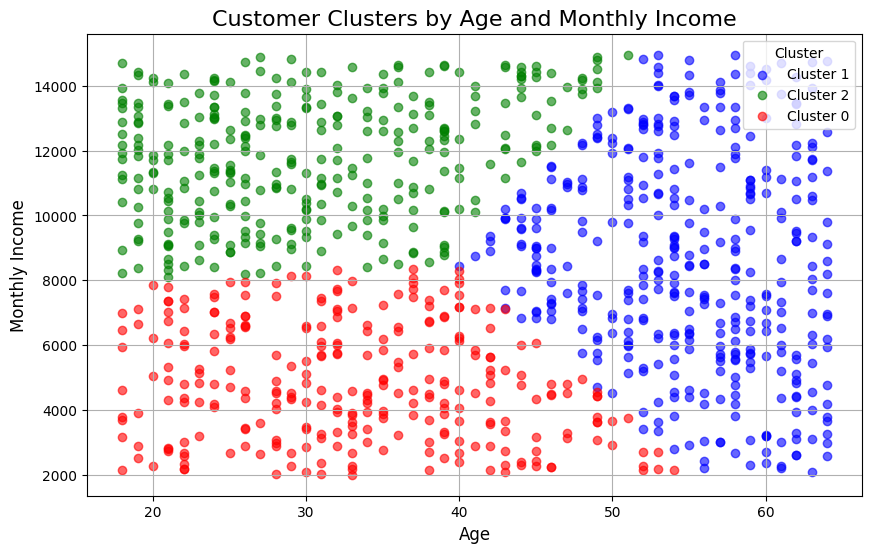

Target Cluster: 2
Top 3 Regions by Target Customer Count:
 region
R020    36
R027    32
R019    30
Name: count, dtype: int64

Selected Region: R020


In [ ]:
# 필요한 라이브러리 임포트
from sklearn.cluster import KMeans  # K-평균 클러스터링을 위한 라이브러리
from sklearn.preprocessing import StandardScaler  # 데이터 표준화를 위한 라이브러리
import matplotlib.pyplot as plt  # 시각화를 위한 라이브러리
import pandas as pd  # 데이터 프레임 처리를 위한 라이브러리
from apyori import apriori  # Apriori 알고리즘을 위한 라이브러리

# 고객 데이터 불러오기
customer_data = pd.read_csv("customer.csv")  # customer.csv 파일에서 데이터 로드

# 특성(feature) 스케일링 (표준화)
scaler = StandardScaler()  # StandardScaler 객체 생성
customer_scaled = scaler.fit_transform(customer_data[['age', 'monthly_income']])  # 'age'와 'monthly_income' 특성을 표준화

# K-평균 클러스터링 수행
kmeans = KMeans(n_clusters=3, random_state=42)  # 클러스터 개수 3개로 K-평균 알고리즘 초기화
customer_data['cluster'] = kmeans.fit_predict(customer_scaled)  # 클러스터링 결과를 'cluster' 열에 추가

# 클러스터 분석
cluster_summary = customer_data.groupby('cluster').agg(
    avg_age=('age', 'mean'),  # 클러스터 별 평균 나이
    avg_income=('monthly_income', 'mean'),  # 클러스터 별 평균 월 소득
    count=('customer_id', 'count')  # 클러스터 별 고객 수
).reset_index()  # 인덱스 재설정

# 클러스터 요약 정보 출력
print("Customer Cluster Summary:\n", cluster_summary)  # 클러스터 요약 정보 출력

# 클러스터링 결과의 산점도(Scatter plot) 생성
plt.figure(figsize=(10, 6))  # 그래프 크기 설정
colors = ['red', 'blue', 'green']  # 클러스터 색상 정의

# 각 클러스터에 대해 산점도 생성
for cluster in customer_data['cluster'].unique():  # 고유한 클러스터에 대해 반복
    cluster_data = customer_data[customer_data['cluster'] == cluster]  # 해당 클러스터에 속하는 고객 데이터 필터링
    plt.scatter(cluster_data['age'], cluster_data['monthly_income'],  # 산점도에 나이와 월 소득을 플롯
                color=colors[cluster], label=f'Cluster {cluster}', alpha=0.6)  # 색상, 레이블, 투명도 설정

# 그래프에 추가 정보 추가
plt.title("Customer Clusters by Age and Monthly Income", fontsize=16)  # 제목 추가
plt.xlabel("Age", fontsize=12)  # x축 레이블 추가
plt.ylabel("Monthly Income", fontsize=12)  # y축 레이블 추가
plt.legend(title="Cluster", fontsize=10)  # 범례 추가
plt.grid(True)  # 그리드 추가
plt.show()  # 그래프 표시

# 목표 클러스터 식별
target_cluster = cluster_summary['cluster'][cluster_summary['avg_income'].idxmax()]  # 평균 소득이 가장 높은 클러스터 선택
print("Target Cluster:", target_cluster)  # 목표 클러스터 출력

# 목표 클러스터에 속하는 고객 필터링 및 상위 지역 식별
target_customers = customer_data[customer_data['cluster'] == target_cluster]  # 목표 클러스터에 속하는 고객 데이터 필터링

# 목표 고객이 많은 상위 3개 지역 추출
top_3_regions = target_customers['region'].value_counts().head(3)  # 상위 3개 지역 추출
print("Top 3 Regions by Target Customer Count:\n", top_3_regions)  # 상위 3개 지역 출력

# 상위 지역 선택
top_region = top_3_regions.idxmax()  # 고객 수가 가장 많은 지역 선택
print("\nSelected Region:", top_region)  # 선택된 지역 출력


### 문제 3: 세트 상품구성

In [ ]:
# 거래 데이터 불러오기
transaction_data_df = pd.read_csv("transaction.csv")  # transaction.csv 파일에서 데이터 로드

# 선택된 지역의 거래 데이터 필터링
filtered_transaction_data = transaction_data_df[transaction_data_df['region'] == top_region]  # 선택된 지역의 거래 데이터 필터링

# Apriori 분석을 위한 거래 데이터 준비
transactions = filtered_transaction_data.groupby('transaction_id')['product'].apply(list).tolist()  # 거래 ID별로 상품 목록을 리스트로 변환

# Apriori 알고리즘 적용 (최소 지지도 낮게 설정)
results = list(apriori(transactions, min_support=0.2, min_confidence=0.7))  # 지지도와 신뢰도 조건으로 Apriori 알고리즘 적용

# 자주 발생하는 품목 집합(frequent itemsets) 결과 분석
parsed_results = [
    {'items': res.items, 'support': res.support}  # 품목 집합과 지지도 추출
    for res in results if len(res.items) > 1  # 품목 집합의 크기가 2 이상인 것만 필터링
]

# 지지도 내림차순으로 정렬 후 상위 3개 집합 선택
top_3_sets = sorted(parsed_results, key=lambda x: x['support'], reverse=True)[:3]  # 상위 3개의 품목 집합 선택

# 상위 3개의 세트 상품 가격 계산
product_avg = filtered_transaction_data.groupby('product')['amount'].mean().reset_index()  # 상품별 평균 금액 계산
product_avg.columns = ['product', 'average_amount']  # 컬럼 이름 변경

set_prices = []
for idx, itemset in enumerate(top_3_sets, start=1):
    items = itemset['items']  # 품목 집합 추출
    base_price = product_avg[product_avg['product'].isin(items)]['average_amount'].sum()  # 품목의 총 금액 계산
    discounted_price = base_price * 0.9  # 10% 할인된 가격 계산
    set_prices.append({
        'set_name': f"세트상품 {chr(64 + idx)}",  # 세트 상품 이름 지정
        'items': ", ".join(items),  # 품목 이름 연결
        'base_price': round(base_price, 2),  # 기본 가격 (소수점 둘째 자리 반올림)
        'discounted_price': round(discounted_price, 2)  # 할인 가격 (소수점 둘째 자리 반올림)
    })

# 세트 상품 가격을 데이터프레임으로 변환
set_prices_df = pd.DataFrame(set_prices)  # 세트 상품 가격 정보 데이터프레임 생성

# 세트 상품 가격 출력
print("\nSet Product Prices for Selected Region:")  # 출력 제목 추가
print(set_prices_df)  # 세트 상품 가격 데이터프레임 출력



Set Product Prices for Selected Region:
  set_name                 items  base_price  discounted_price
0   세트상품 A      Americano, Scone    12934.36          11640.93
1   세트상품 B  Americano, Croissant    13754.48          12379.04
2   세트상품 C          Latte, Scone    15726.18          14153.56
